1. Movie Recommendation System
   - Dataset Loading
   - Data Preprocessing
   - Feature Engineering
   - TF-IDF Vectorization
   - Cosine Similarity
   - Recommendations


In [12]:
# =====================================
# Movie Recommendation System
# TF-IDF + Cosine Similarity
# =====================================

import pandas as pd
import ast
import os
import kagglehub

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =====================================
# Download Dataset
# =====================================

print("Downloading dataset...")

dataset_path = kagglehub.dataset_download(
    "tmdb/tmdb-movie-metadata"
)

print("Dataset Path:", dataset_path)

# =====================================
# Load Data
# =====================================

movies_file = os.path.join(
    dataset_path,
    "tmdb_5000_movies.csv"
)

credits_file = os.path.join(
    dataset_path,
    "tmdb_5000_credits.csv"
)

movies = pd.read_csv(movies_file)
credits = pd.read_csv(credits_file)

print("Movies Shape:", movies.shape)
print("Credits Shape:", credits.shape)

# =====================================
# Merge Datasets
# =====================================

movies = movies.merge(
    credits,
    on="title",
    how="inner"
)

movies = movies.drop_duplicates(
    subset="title"
)

# =====================================
# Select Required Columns
# =====================================

movies = movies[
    [
        "movie_id",
        "title",
        "overview",
        "genres",
        "keywords",
        "cast",
        "crew"
    ]
]

movies.dropna(inplace=True)

print("After Cleaning:", movies.shape)

# =====================================
# Helper Functions
# =====================================

def convert(text):
    result = []

    for item in ast.literal_eval(text):
        result.append(item["name"])

    return result


def fetch_director(text):

    result = []

    for item in ast.literal_eval(text):

        if item["job"] == "Director":
            result.append(item["name"])

    return result


# =====================================
# Process Columns
# =====================================

movies["genres"] = movies["genres"].apply(convert)

movies["keywords"] = movies["keywords"].apply(convert)

movies["cast"] = movies["cast"].apply(
    lambda x: convert(x)[:3]
)

movies["crew"] = movies["crew"].apply(
    fetch_director
)

movies["overview"] = movies["overview"].apply(
    lambda x: x.split()
)

# Remove spaces

for col in ["genres", "keywords", "cast", "crew"]:

    movies[col] = movies[col].apply(
        lambda x: [i.replace(" ", "") for i in x]
    )

# =====================================
# Create Tags
# =====================================

movies["tags"] = (
    movies["overview"]
    + movies["genres"]
    + movies["keywords"]
    + movies["cast"]
    + movies["crew"]
)

movies["tags"] = movies["tags"].apply(
    lambda x: " ".join(x).lower()
)

# =====================================
# TF-IDF Vectorization
# =====================================

print("Creating TF-IDF vectors...")

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

vectors = tfidf.fit_transform(
    movies["tags"]
)

# =====================================
# Similarity Matrix
# =====================================

print("Calculating similarity matrix...")

similarity = cosine_similarity(vectors)

print("Similarity Matrix Shape:",
      similarity.shape)

# =====================================
# Recommendation Function
# =====================================

def recommend(movie_name, top_n=10):

    movie_name = movie_name.lower()

    titles = movies["title"].str.lower()

    if movie_name not in titles.values:

        print(
            f"\nMovie '{movie_name}' not found!"
        )
        return

    idx = titles[
        titles == movie_name
    ].index[0]

    scores = list(
        enumerate(similarity[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    print(
        f"\nTop {top_n} Recommendations "
        f"for '{movie_name.title()}':\n"
    )

    for movie in scores[1:top_n+1]:

        print(
            movies.iloc[movie[0]]["title"]
        )

# =====================================
# Examples
# =====================================

def recommend(movie_name, top_n=10):

    movie_name = movie_name.lower()
    titles = movies["title"].str.lower()

    if movie_name not in titles.values:
        return pd.DataFrame(
            {"Error": ["Movie not found"]}
        )

    idx = titles[titles == movie_name].index[0]

    scores = list(
        enumerate(similarity[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for movie in scores[1:top_n+1]:

        recommendations.append({
            "Movie":
            movies.iloc[movie[0]]["title"],

            "Similarity Score":
            round(movie[1], 4)
        })

    return pd.DataFrame(recommendations)

print(
    recommend("Avatar")
)
print("\nDataset Statistics")
print(f"Total Movies: {len(movies)}")
print(f"Feature Matrix Shape: {vectors.shape}")
print(f"Similarity Matrix Shape: {similarity.shape}")

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Dataset Path: /kaggle/input/tmdb-movie-metadata
Movies Shape: (4803, 20)
Credits Shape: (4803, 4)
After Cleaning: (4797, 7)
Creating TF-IDF vectors...
Calculating similarity matrix...
Similarity Matrix Shape: (4797, 4797)
                     Movie  Similarity Score
0            Falcon Rising            0.2037
1      Battle: Los Angeles            0.1977
2                Apollo 18            0.1841
3  Star Trek Into Darkness            0.1713
4                Predators            0.1663
5               Titan A.E.            0.1655
6                   Aliens            0.1628
7         The Book of Life            0.1627
8             Ender's Game            0.1604
9                  Jarhead            0.1558

Dataset Statistics
Total Movies: 4797
Feature Matrix Shape: (4797, 5000)
Similarity Matrix Shape: (4797, 4797)


2. Stock Price Prediction using LSTM
   - Data Collection
   - Data Preprocessing
   - Model Building
   - Evaluation
   - Prediction

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


X Shape: (1198, 60, 1)
y Shape: (1198,)
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0350 - val_loss: 0.0039
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0028 - val_loss: 0.0045
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0026 - val_loss: 0.0052
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0020 - val_loss: 0.0057
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0021 - val_loss: 0.0078
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0018 - val_loss: 0.0031
Epoch 9/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 10/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 11/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 12/25
30/30 ━━━━

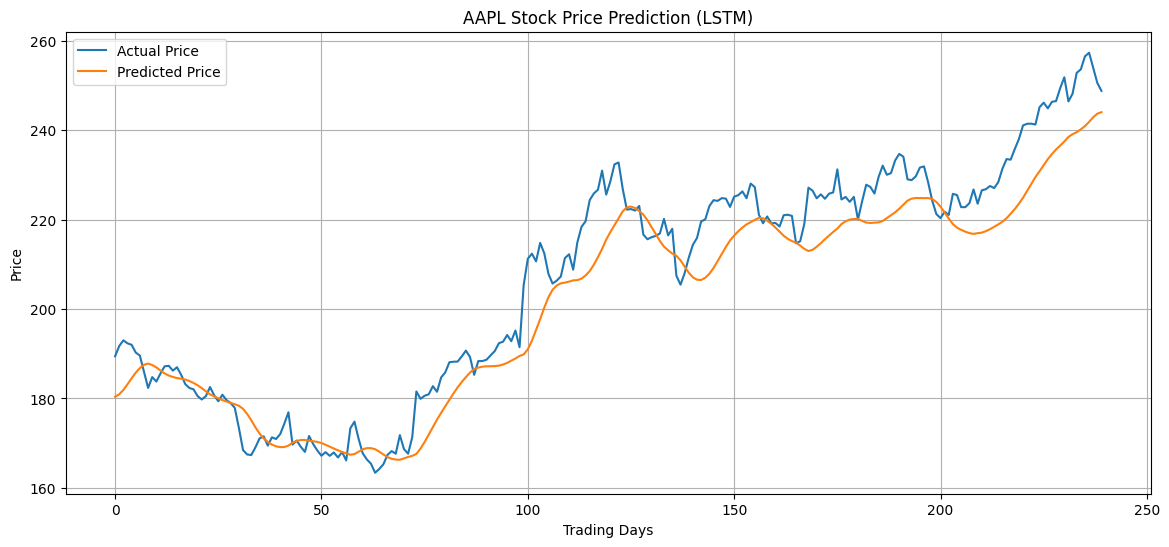

In [8]:
!pip install yfinance tensorflow scikit-learn matplotlib
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ==========================
# Download Data
# ==========================

ticker = "AAPL"

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Handle MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

close_prices = data["Close"].values.reshape(-1, 1)

# ==========================
# Scale Data
# ==========================

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

# ==========================
# Create Sequences
# ==========================

window_size = 60

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# ==========================
# Train-Test Split
# ==========================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ==========================
# Build LSTM Model
# ==========================

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# ==========================
# Train Model
# ==========================

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================
# Predictions
# ==========================

predictions = model.predict(X_test)

# Convert back to actual prices
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

# ==========================
# Metrics
# ==========================

mse = mean_squared_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test_actual,
    predictions
)

r2 = r2_score(
    y_test_actual,
    predictions
)

print("\n===== MODEL PERFORMANCE =====")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ==========================
# Predict Next Day
# ==========================

last_60_days = scaled_data[-60:]

X_future = np.array([last_60_days])
X_future = X_future.reshape(
    1,
    window_size,
    1
)

next_day_scaled = model.predict(X_future)

next_day_price = scaler.inverse_transform(
    next_day_scaled
)

print("\n===== NEXT DAY FORECAST =====")
print(
    f"Current Close Price: "
    f"{close_prices[-1][0]:.2f}"
)

print(
    f"Predicted Next Close: "
    f"{next_day_price[0][0]:.2f}"
)

# ==========================
# Plot Results
# ==========================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title(
    f"{ticker} Stock Price Prediction (LSTM)"
)

plt.xlabel("Trading Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

Count of #34a853 cells: 0


Counter({"#'STR'>": 85})


🎉 Stylish template created: Daily_Diary_Major_2025.xlsx
✅ Entry added for 2025-09-18
✅ Entry added for 2025-09-25
✅ Entry added for 2025-09-30
✅ Entry added for 2025-10-03
